# Qual è la competenza più ottimale da acquisire per un analista di dati? 
Metodologia 
1. Raggruppare le competenze per determinare lo stipendio mediano e la probabilità di essere inclusi nell'annuncio 
2. Visualizzare lo stipendio mediano rispetto alla percentuale di domanda di competenze 
3. (Facoltativo) Determinare se determinate tecnologie sono più diffuse

In [1]:
# Importare le librerie necessarie
import ast
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from datasets import load_dataset
from typing import cast

# Caricare il dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = cast(pd.DataFrame, dataset['train'].to_pandas())

# Pulire i dati
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [8]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US.dropna(subset=['salary_year_avg'], inplace=True)
df_DA_US_explode = df_DA_US.explode('job_skills')
df_DA_US_explode.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,python,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,r,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,alteryx,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,tableau,"{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
180,Data Analyst,Data Analyst III,"Dos Palos, CA",via My ArkLaMiss Jobs,Full-time,False,"California, United States",2023-02-27 13:00:39,False,True,United States,year,90250.0,NaN,California Health & Wellness,excel,"{'analyst_tools': ['excel', 'powerpoint']}"


In [13]:
df_DA_skills = df_DA_US_explode.groupby('job_skills')['salary_year_avg'].agg(['median', 'count']).sort_values(by='count', ascending=False)
df_DA_skills = df_DA_skills.rename(columns={'median': 'median_salary', 'count': 'skill_count'})
DA_jobs_count = len(df_DA_US)
df_DA_skills['skill_percent'] = (df_DA_skills['skill_count'] / DA_jobs_count) * 100
df_DA_skills

,median_salary,skill_count,skill_percent
job_skills,,,
sql,91000.0,2508,57.655172
excel,84392.0,1808,41.563218
python,97500.0,1431,32.896552
tableau,92875.0,1364,31.356322
sas,90000.0,926,21.287356
...,...,...,...
couchbase,160515.0,1,0.022989
chainer,100000.0,1,0.022989
chef,85000.0,1,0.022989


In [14]:
skill_percent = 5
df_DA_skills_hight_demand = df_DA_skills[df_DA_skills['skill_percent'] >= skill_percent]
df_DA_skills_hight_demand

,median_salary,skill_count,skill_percent
job_skills,,,
sql,91000.00,2508,57.655172
excel,84392.00,1808,41.563218
python,97500.00,1431,32.896552
tableau,92875.00,1364,31.356322
sas,90000.00,926,21.287356
r,92500.00,893,20.528736
power bi,90000.00,838,19.264368
powerpoint,85000.00,462,10.620690
word,81194.75,461,10.597701


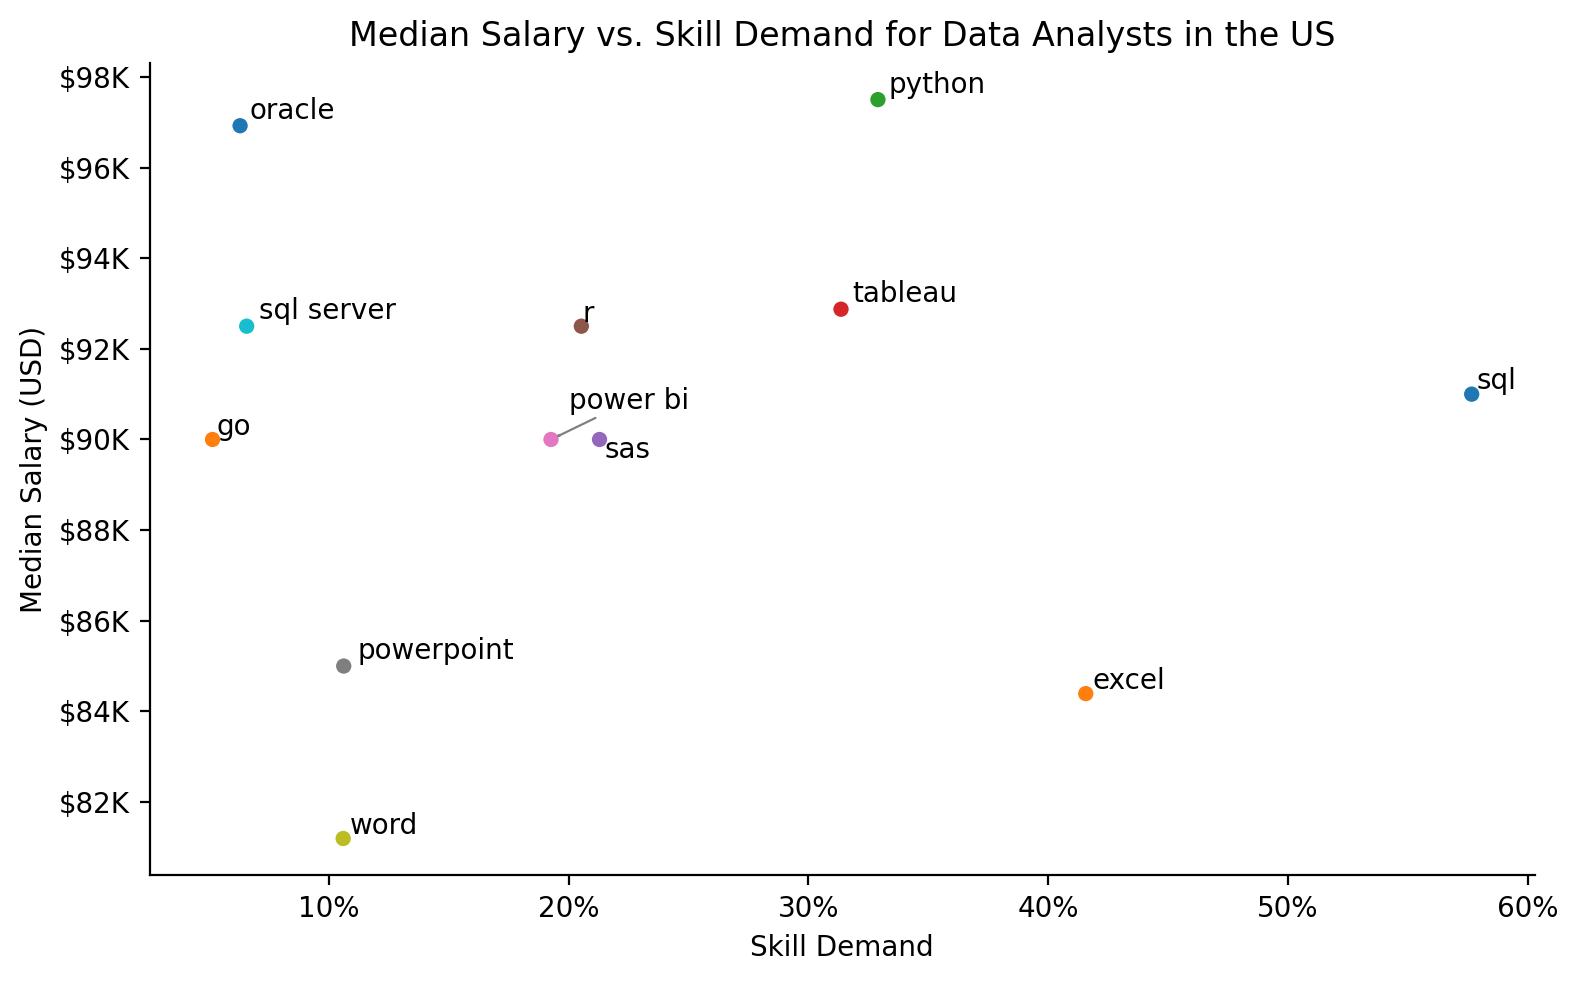

In [63]:
%config InlineBackend.figure_format = 'retina'
from adjustText import adjust_text

# Ingrandiamo la figura per dare più spazio alle etichette
plt.figure(figsize=(8, 5))

# Scatterplot
sns.scatterplot(data=df_DA_skills_hight_demand, y='median_salary', x='skill_percent', hue=df_DA_skills_hight_demand.index, palette='tab10')
sns.despine()

plt.title('Median Salary vs. Skill Demand for Data Analysts in the US')
plt.xlabel('Skill Demand')
plt.ylabel('Median Salary (USD)')
plt.legend().remove()

# Aggiunta di etichette per ogni punto usando adjustText
texts = []
for i, row in df_DA_skills_hight_demand.iterrows():
    texts.append(plt.text(row['skill_percent'], row['median_salary'], i)) # type: ignore

# adjust_text funziona meglio se ha abbastanza spazio. Torniamo a valori più conservativi o default.
adjust_text(texts, 
            arrowprops=dict(arrowstyle='->', color='grey', lw=0.8))

ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}%')) # formatta l'asse x per mostrare le percentuali
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K')) # formatta l'asse y per mostrare i salari in migliaia di dollari

plt.tight_layout()
plt.savefig('images/optimal_skills_scatterplot.svg', format='svg')